# 🏠 House Prices - Exploratory Data Analysis (EDA)

Tento notebook obsahuje kompletní exploratorní analýzu dat pro projekt predikce cen nemovitostí.

## 📋 Obsah:

1. **Načtení a základní přehled dat**
2. **Analýza cílové proměnné (SalePrice)**
3. **Korelační analýza**
4. **Analýza missing values**
5. **Detekce outlierů**
6. **Analýza kategorických proměnných**

---

**📝 Poznámka:** Po dokončení EDA pokračuj v notebooku `02_Preprocessing.ipynb` pro přípravu dat.


In [2]:
# 📦 Import knihoven
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# 🎨 Nastavení vizualizací
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# 📂 Import vlastních modulů
import sys
sys.path.append('..')
from src.data_loader import DataLoader

# 📍 Nastavení cest
PROJECT_DIR = Path('..')
DATA_DIR = PROJECT_DIR / 'data'
RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print("✅ Všechny knihovny načteny!")


✅ Všechny knihovny načteny!


---

# 1️⃣ EXPLORATORY DATA ANALYSIS (EDA)

## 1.1 Načtení dat


In [3]:
# Načtení dat
loader = DataLoader(data_dir=str(DATA_DIR))
train = loader.load_train_data()
test = loader.load_test_data()

print(f"✅ Train shape: {train.shape}")
print(f"✅ Test shape: {test.shape}")
print(f"\n📊 První řádky train dat:")
train.head()


✅ Train shape: (1460, 81)
✅ Test shape: (1459, 80)

📊 První řádky train dat:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Základní informace o datech
print("=" * 80)
print("📊 ZÁKLADNÍ PŘEHLED DAT")
print("=" * 80)

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 Numerické features: {len(numeric_cols)}")
print(f"📦 Kategorické features: {len(categorical_cols)}")
print(f"❓ Celkem missing values: {train.isnull().sum().sum()}")

# Info o datových typech
print(f"\n💾 Memory usage: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


📊 ZÁKLADNÍ PŘEHLED DAT

📈 Numerické features: 38
📦 Kategorické features: 43
❓ Celkem missing values: 7829

💾 Memory usage: 3.86 MB


## 1.3 Analýza cílové proměnné (SalePrice)


💰 ANALÝZA SALEPRICE

📊 Základní statistiky:
   Mean:   $     180,921
   Median: $     163,000
   Std:    $      79,443
   Min:    $      34,900
   Max:    $     755,000

📈 Rozložení:
   Skewness: 1.883
   Kurtosis: 6.536


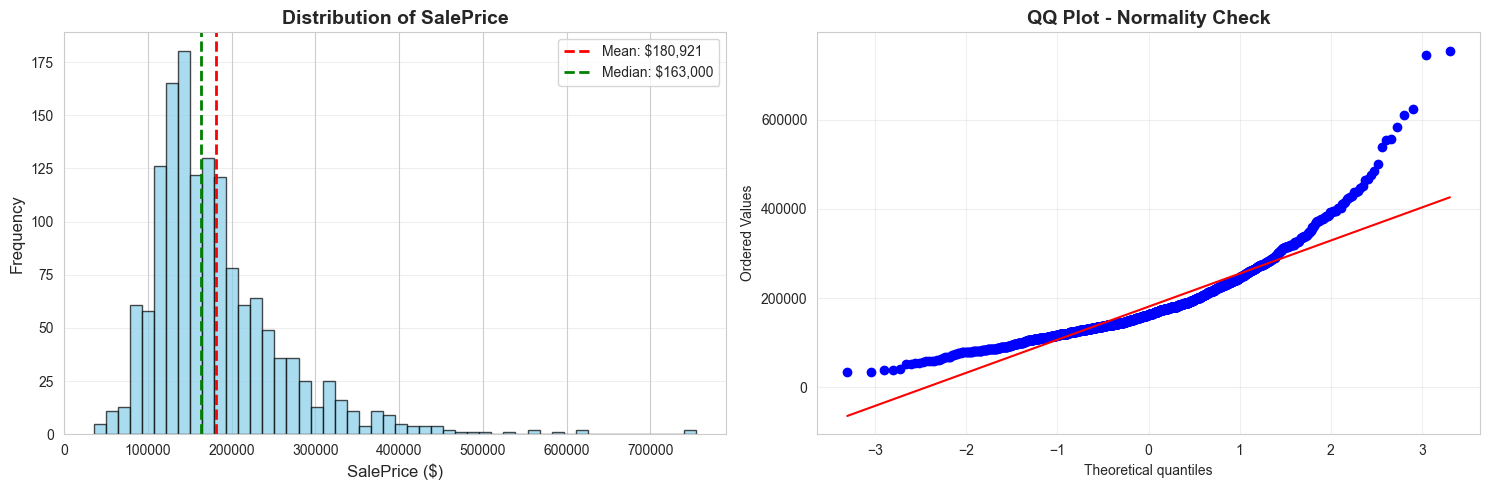


🔄 Po log transformaci:
   Skewness: 0.121
   ✅ Log transformace výrazně snižuje skewness!


In [5]:
# Statistické charakteristiky SalePrice
print("=" * 80)
print("💰 ANALÝZA SALEPRICE")
print("=" * 80)

print(f"\n📊 Základní statistiky:")
print(f"   Mean:   ${train['SalePrice'].mean():>12,.0f}")
print(f"   Median: ${train['SalePrice'].median():>12,.0f}")
print(f"   Std:    ${train['SalePrice'].std():>12,.0f}")
print(f"   Min:    ${train['SalePrice'].min():>12,.0f}")
print(f"   Max:    ${train['SalePrice'].max():>12,.0f}")

print(f"\n📈 Rozložení:")
print(f"   Skewness: {train['SalePrice'].skew():.3f}")
print(f"   Kurtosis: {train['SalePrice'].kurtosis():.3f}")

# Vizualizace distribuce
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(train['SalePrice'], bins=50, edgecolor='black', color='skyblue', alpha=0.7)
axes[0].axvline(train['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${train["SalePrice"].mean():,.0f}')
axes[0].axvline(train['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${train["SalePrice"].median():,.0f}')
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of SalePrice', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# QQ plot
stats.probplot(train['SalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot - Normality Check', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Log transformace
print(f"\n🔄 Po log transformaci:")
print(f"   Skewness: {np.log1p(train['SalePrice']).skew():.3f}")
print(f"   ✅ Log transformace výrazně snižuje skewness!")


## 1.4 Korelační analýza


🔗 KORELAČNÍ ANALÝZA

📊 Top 15 pozitivních korelací:
    1. OverallQual               :  0.791
    2. GrLivArea                 :  0.709
    3. GarageCars                :  0.640
    4. GarageArea                :  0.623
    5. TotalBsmtSF               :  0.614
    6. 1stFlrSF                  :  0.606
    7. FullBath                  :  0.561
    8. TotRmsAbvGrd              :  0.534
    9. YearBuilt                 :  0.523
   10. YearRemodAdd              :  0.507
   11. GarageYrBlt               :  0.486
   12. MasVnrArea                :  0.477
   13. Fireplaces                :  0.467
   14. BsmtFinSF1                :  0.386
   15. LotFrontage               :  0.352


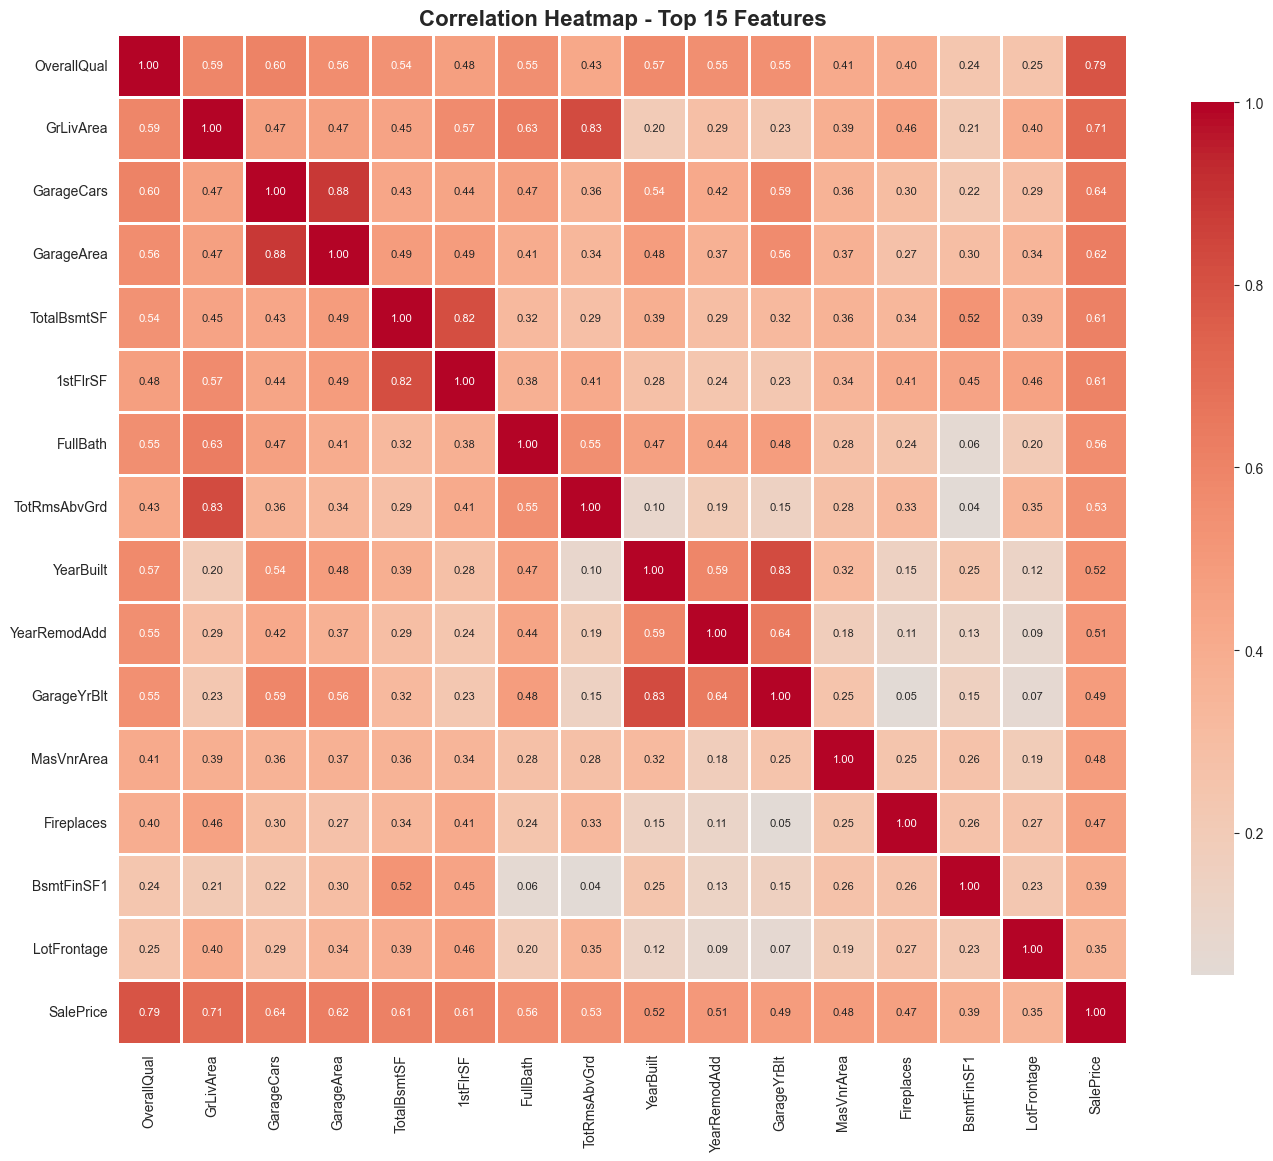

In [6]:
# Korelace s SalePrice
print("=" * 80)
print("🔗 KORELAČNÍ ANALÝZA")
print("=" * 80)

correlations = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("\n📊 Top 15 pozitivních korelací:")
for i, (feature, corr) in enumerate(correlations[1:16].items(), 1):
    print(f"   {i:2d}. {feature:25s} : {corr:6.3f}")

# Heatmap top korelací
top_corr_features = correlations[1:16].index.tolist() + ['SalePrice']
corr_matrix = train[top_corr_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})
plt.title('Correlation Heatmap - Top 15 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.5 Scatter plots - Top features vs SalePrice


In [ ]:
# Scatter plots pro top 5 features
top_5_features = correlations[1:6].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_5_features):
    axes[idx].scatter(train[feature], train['SalePrice'], alpha=0.5, s=20)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('SalePrice ($)', fontsize=11)
    axes[idx].set_title(f'{feature} vs SalePrice\nCorr: {correlations[feature]:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

# Odstraníme poslední prázdný subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_scatter_plots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.6 Analýza missing values


In [ ]:
# Missing values analýza
print("=" * 80)
print("❓ ANALÝZA MISSING VALUES")
print("=" * 80)

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(f"\n📊 Celkem sloupců s missing values: {len(missing)}")
    print(f"📊 Celkem missing values: {missing.sum()}")
    print("\n📋 Top 15 sloupců s missing values:")
    for i, (col, count) in enumerate(missing.head(15).items(), 1):
        pct = (count / len(train)) * 100
        print(f"   {i:2d}. {col:25s} : {count:4d} ({pct:5.1f}%)")
    
    # Graf missing values
    plt.figure(figsize=(12, 8))
    missing.head(20).plot(kind='barh', color='salmon')
    plt.xlabel('Number of Missing Values', fontsize=12)
    plt.title('Missing Values by Feature (Top 20)', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '04_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   ✅ Žádné chybějící hodnoty!")


## 1.7 Analýza kategorických proměnných


In [ ]:
# Neighborhood analýza
if 'Neighborhood' in train.columns:
    print("=" * 80)
    print("🏘️  NEIGHBORHOOD - MEDIAN CENY")
    print("=" * 80)
    
    neighborhood_prices = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
    
    print("\n📊 Top 10 nejdražších čtvrtí:")
    for i, (neighborhood, price) in enumerate(neighborhood_prices.head(10).items(), 1):
        print(f"   {i:2d}. {neighborhood:20s} : ${price:>10,.0f}")
    
    # Graf
    plt.figure(figsize=(14, 6))
    neighborhood_prices.plot(kind='bar', color='steelblue')
    plt.xlabel('Neighborhood', fontsize=12)
    plt.ylabel('Median SalePrice ($)', fontsize=12)
    plt.title('Median SalePrice by Neighborhood', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '05_neighborhood_prices.png', dpi=150, bbox_inches='tight')
    plt.show()

# OverallQual analýza
if 'OverallQual' in train.columns:
    plt.figure(figsize=(12, 6))
    train.boxplot(column='SalePrice', by='OverallQual', ax=plt.gca())
    plt.xlabel('Overall Quality (1-10)', fontsize=12)
    plt.ylabel('SalePrice ($)', fontsize=12)
    plt.title('SalePrice by Overall Quality', fontsize=14, fontweight='bold')
    plt.suptitle('')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '06_quality_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


## 1.8 Detekce outlierů


In [ ]:
# Detekce outlierů v GrLivArea
print("=" * 80)
print("🎯 DETEKCE OUTLIERŮ")
print("=" * 80)

if 'GrLivArea' in train.columns:
    Q1 = train['GrLivArea'].quantile(0.25)
    Q3 = train['GrLivArea'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train[(train['GrLivArea'] < Q1 - 1.5 * IQR) | 
                     (train['GrLivArea'] > Q3 + 1.5 * IQR)]
    
    print(f"\n📊 GrLivArea outliers (IQR metoda): {len(outliers)} domů")
    
    # Vizualizace
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Scatter plot s outliery
    axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, s=20, label='Normal')
    axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'], 
                   color='red', s=100, alpha=0.7, label='Outliers', marker='x')
    axes[0].set_xlabel('GrLivArea (sq ft)', fontsize=12)
    axes[0].set_ylabel('SalePrice ($)', fontsize=12)
    axes[0].set_title('GrLivArea vs SalePrice - Outliers', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(train['GrLivArea'])
    axes[1].set_ylabel('GrLivArea (sq ft)', fontsize=12)
    axes[1].set_title('GrLivArea Boxplot', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '07_outliers.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Extrémní outliery (GrLivArea > 4000 a nízká cena)
    extreme_outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
    print(f"⚠️  Extrémní outliery (GrLivArea > 4000, cena < $300k): {len(extreme_outliers)}")
    if len(extreme_outliers) > 0:
        print("   Indexy:", extreme_outliers.index.tolist())


---

# 📝 ZÁVĚRY Z EDA

## Klíčové poznatky:

1. **SalePrice je výrazně skewed** → doporučena log transformace
2. **Missing values** jsou v mnoha sloupcích → je třeba je vyřešit
3. **Nejdůležitější features** pro predikci ceny:
   - OverallQual
   - GrLivArea
   - TotalBsmtSF
   - GarageCars
   - YearBuilt
4. **Outliers** v GrLivArea → zvážit odstranění extrémních hodnot
5. **Kategorické proměnné** (Neighborhood, OverallQual) mají významný vliv na cenu

---

**➡️ Další krok:** Otevři notebook `02_Preprocessing.ipynb` pro přípravu dat pro modelování.
